In [4]:
# 1. Imports
import pandas as pd
import numpy as np
import re
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
# 2. Load dataset
DATA_CSV =r"C:\Users\Hp\Downloads\placement_dataset_1200.csv"# path to the CSV you created earlier
df = pd.read_csv(DATA_CSV)
df.shape, df.head(3)

((1200, 13),
            name                                           skills  \
 0    Aarav Nair  Deep Learning, Computer Vision, Arduino, Python   
 1   Ananya Khan                      Computer Vision, Blockchain   
 2  Kabir Pandey                                 JavaScript, HTML   
 
    project_count internship  communication branch  cgpa  \
 0              3        Yes              2  Other  8.24   
 1              0         No              2     IT  6.62   
 2              1         No              4    CSE  8.71   
 
                     certificates backlogs  marks_10  marks_12  \
 0           Python for Everybody       No     72.40     84.97   
 1   Deep Learning Specialization       No     91.68     73.57   
 2  Google IT Support Certificate       No     83.26     82.25   
 
            interest_domain  placed  
 0  Artificial Intelligence       1  
 1          Computer Vision       1  
 2          Web Development       1  )

In [12]:
# 3. Quick sanity: required columns
expected_cols = ['skills','project_count','internship','communication','cgpa','backlogs','marks_10','marks_12','interest_domain','placed']
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")
print("All required columns present.")

All required columns present.


In [21]:
# 4. Basic feature engineering
# 4.1 Certificates -> cert_count (optional)
df['cert_count'] = df['certificates'].fillna("").apply(lambda s: len([x for x in s.split(',') if x.strip()!='']))

# 4.2 Skills tokenization helper
def tokenize_skills(text):
    if not isinstance(text, str) or text.strip()=="":
        return []
    tokens = re.split(r'[,\;/\|]+', text)
    return [t.strip().lower() for t in tokens if t.strip()!='']

df['skills_tokens'] = df['skills'].fillna("").apply(tokenize_skills)
df['skills_count'] = df['skills_tokens'].apply(len)
df['skills_joined'] = df['skills_tokens'].apply(lambda toks: " ".join(toks))

# 4.3 Domain required skills mapping (same you used earlier)
domain_required_skills = {
    "Data Science": ["python","sql","data analysis","machine learning"],
    "Machine Learning": ["python","machine learning","deep learning","data analysis"],
    "Artificial Intelligence": ["python","machine learning","deep learning","computer vision"],
    "Web Development": ["html","css","javascript","react"],
    "Mobile Application Development": ["java","kotlin","swift","android development"],
    "Cloud Computing": ["cloud computing","docker","kubernetes","linux"],
    "Cyber Security": ["cyber security","networking","linux"],
    "Internet of Things (IoT)": ["embedded systems","c/c++","python"],
    "Robotics": ["embedded systems","control systems","python"],
    "Blockchain Technology": ["blockchain","solidity","cryptography"],
    "Software Testing": ["software testing","selenium","automation"],
    "DevOps": ["docker","kubernetes","ci/cd"],
    "Networking": ["networking","cisco","network security"],
    "Database Management": ["sql","database design"],
    "UI/UX Design": ["ui/ux design","figma"],
    "Digital Marketing": ["digital marketing","seo"],
    "Embedded Systems": ["embedded systems","c/c++"],
    "Computer Vision": ["computer vision","deep learning","opencv"],
    "Natural Language Processing (NLP)": ["nlp","python","transformers"],
    "Big Data Analytics": ["big data","spark","hadoop"],
    "Software Development": ["python","java","c++","data structures"],
    "Information Technology (IT) Support": ["it support","hardware","networking"],
    "Project Management": ["project management","agile"],
    "Data Engineering": ["sql","etl","big data"]
}

def domain_skill_match_ratio(skills_tokens, domain):
    req = domain_required_skills.get(domain, [])
    if len(req) == 0:
        return 0.0
    matched = sum(1 for r in req if r.lower() in skills_tokens)
    return matched / len(req)

df['domain_skill_match_ratio'] = df.apply(lambda r: domain_skill_match_ratio(r['skills_tokens'], r['interest_domain']), axis=1)

# 4.4 Encode 'internship' and 'backlogs' as binary (keep label encoders too)
le_intern = LabelEncoder().fit(df['internship'].astype(str))
le_backlogs = LabelEncoder().fit(df['backlogs'].astype(str))
le_domain = LabelEncoder().fit(df['interest_domain'].astype(str))

df['internship_enc'] = le_intern.transform(df['internship'].astype(str))
df['backlogs_enc'] = le_backlogs.transform(df['backlogs'].astype(str))
df['interest_domain_enc'] = le_domain.transform(df['interest_domain'].astype(str))



In [23]:
# 5. Text vectorization for skills (Count or TF-IDF). We keep skills as text feature but vectorize for model.
vectorizer = TfidfVectorizer(max_features=300, ngram_range=(1,2))  # TF-IDF often works better than raw counts
X_skills = vectorizer.fit_transform(df['skills_joined'])


In [25]:
# 6. Numeric features list
numeric_cols = ['project_count','communication','cgpa','marks_10','marks_12','cert_count','skills_count','domain_skill_match_ratio','internship_enc','backlogs_enc','interest_domain_enc']
X_num = df[numeric_cols].fillna(0).astype(float).values

In [27]:
# 7. Scale numeric features
scaler = StandardScaler().fit(X_num)
X_num_scaled = scaler.transform(X_num)

In [29]:
# 8. Combine sparse skill vectors and numeric features
X_all = hstack([X_skills, X_num_scaled])   # requires from scipy.sparse import hstack (already imported above)

In [31]:
# 9. Target
y = df['placed'].astype(int).values

In [33]:
# 10. Train/test split (stratify by label for balanced eval)
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
# 11. Train a strong baseline model: RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
# 12. Optionally calibrate probabilities (recommended for "chance %")
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(estimator=rf, method='isotonic', cv=5)
calibrated.fit(X_train, y_train)


,estimator,RandomForestC...ndom_state=42)
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


Accuracy: 0.575
ROC AUC: 0.5903694392066485
              precision    recall  f1-score   support

           0       0.58      0.73      0.65       129
           1       0.56      0.40      0.46       111

    accuracy                           0.57       240
   macro avg       0.57      0.56      0.56       240
weighted avg       0.57      0.57      0.56       240



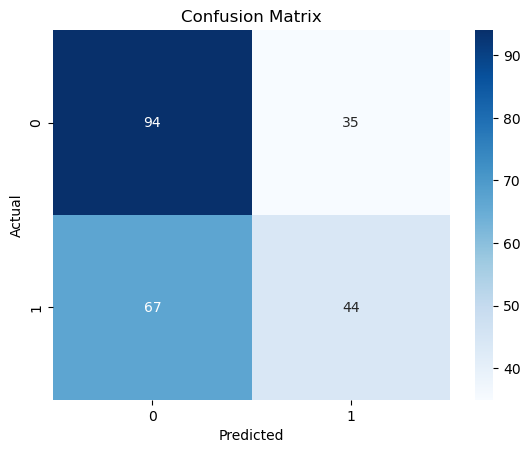

In [41]:
# 13. Evaluate
y_pred = calibrated.predict(X_test)
y_proba = calibrated.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()


In [43]:
# 14. Feature importance (approx): for combined sparse + dense, get importance for numeric part by training on numeric only
rf_num = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_num.fit(X_num_scaled, y)
importances_num = rf_num.feature_importances_
feat_imp = pd.Series(importances_num, index=numeric_cols).sort_values(ascending=False)
print("Numeric feature importance:\n", feat_imp)

Numeric feature importance:
 marks_12                    0.185532
cgpa                        0.177385
marks_10                    0.172900
interest_domain_enc         0.128041
skills_count                0.070714
domain_skill_match_ratio    0.069950
communication               0.066082
project_count               0.062152
internship_enc              0.025765
cert_count                  0.021797
backlogs_enc                0.019681
dtype: float64


In [45]:
# 15. Save model and preprocessor objects
joblib.dump(calibrated, "placement_model_calibrated.pkl")
preprocessor = {
    "vectorizer": vectorizer,
    "scaler": scaler,
    "le_intern": le_intern,
    "le_backlogs": le_backlogs,
    "le_domain": le_domain,
    "numeric_cols": numeric_cols,
    "domain_required_skills": domain_required_skills
}
joblib.dump(preprocessor, "preprocessor.pkl")
print("Saved placement_model_calibrated.pkl and preprocessor.pkl")

Saved placement_model_calibrated.pkl and preprocessor.pkl


In [47]:
# 16. Realtime prediction helper (example)
def predict_single(student_dict):
    """
    student_dict must contain keys:
    skills (text), project_count (int), internship ('Yes'/'No'), communication (1-5),
    cgpa (float), backlogs ('Yes'/'No'), marks_10 (float), marks_12 (float), interest_domain (str), certificates (optional text)
    """
    # prepare a single-row DataFrame
    row = pd.DataFrame([student_dict])
    # cert_count
    row['cert_count'] = row['certificates'].fillna("").apply(lambda s: len([x for x in s.split(',') if x.strip()!='']))
    # skills tokens/joined
    row['skills_tokens'] = row['skills'].apply(tokenize_skills)
    row['skills_joined'] = row['skills_tokens'].apply(lambda toks: " ".join(toks))
    row['skills_count'] = row['skills_tokens'].apply(len)
    row['domain_skill_match_ratio'] = row.apply(lambda r: domain_skill_match_ratio(r['skills_tokens'], r['interest_domain']), axis=1)
    # encode categories
    row['internship_enc'] = le_intern.transform(row['internship'].astype(str))
    row['backlogs_enc'] = le_backlogs.transform(row['backlogs'].astype(str))
    # domain: if unseen domain, map to -1 or add handling
    if row['interest_domain'].iloc[0] in list(le_domain.classes_):
        row['interest_domain_enc'] = le_domain.transform(row['interest_domain'].astype(str))
    else:
        # unseen domain -> index -1 (or map to mode). Here we use -1
        row['interest_domain_enc'] = -1

    # numeric features
    Xn = row[numeric_cols].fillna(0).astype(float).values
    Xn_scaled = scaler.transform(Xn)
    Xs = vectorizer.transform(row['skills_joined'])
    Xrow = hstack([Xs, Xn_scaled])
    prob = calibrated.predict_proba(Xrow)[:,1][0]
    return prob*100.0  # percentage

In [55]:
# 17. Test realtime prediction with an example student
example = {
    "skills": "HTML, CSS, JavaScript,Python,React",
    "project_count": 1,
    "internship": "No",
    "communication": 5,
    "cgpa": 7.1,
    "backlogs": "No",
    "marks_10": 88.5,
    "marks_12": 82.0,
    "interest_domain": "Web Development",
    "certificates": "freeCodeCamp Certificate"
}
print("Example predicted placement chance (%):", round(predict_single(example),2))

Example predicted placement chance (%): 57.63


In [57]:
import os
os.getcwd()



'C:\\Users\\Hp'

In [59]:
import os
os.listdir()


['.anaconda',
 '.android',
 '.arduinoIDE',
 '.bash_history',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.dbclient',
 '.eclipse',
 '.gitconfig',
 '.gradle',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.m2',
 '.matplotlib',
 '.mplabcomm',
 '.ms-ad',
 '.netbeans',
 '.node_repl_history',
 '.p2',
 '.packettracer',
 '.spyder-py3',
 '.streamlit',
 '.vscode',
 'anaconda3',
 'AndroidStudioProjects',
 'AppData',
 'Application Data',
 'book-project',
 'Cisco Packet Tracer 8.2.2',
 'Contacts',
 'Cookies',
 'Desktop',
 'dict.ipynb',
 'Documents',
 'Downloads',
 'eclipse',
 'eclipse-workspace',
 'Emotion-detection',
 'Facial_Rcognation',
 'Favorites',
 'file_handling.ipynb',
 'hello.c',
 'IntelGraphicsProfiles',
 'Jedi',
 'Links',
 'Local Settings',
 'loop.ipynb',
 'model.pkl',
 'MPLABXLog.xml.3',
 'MPLABXProjects',
 'Music',
 'My Documents',
 'myenv',
 'NetHood',
 'new_image.jpg',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{a2332f18-cdbf-11ec-8680-